## **Import Libraries**

In [38]:
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import random
import torch
import IPython.display as ipd
from collections import defaultdict
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# CONFIGURATION
DATA_SEED = 67
TRAINING_SEED = 1234
SR = 22050
DURATION = 5.0
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
TOP_DB = 20
TARGET_SNR_DB = 10

random.seed(DATA_SEED)
np.random.seed(DATA_SEED)
torch.manual_seed(DATA_SEED)
torch.cuda.manual_seed(DATA_SEED)

DATA_ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
STEMS = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']
STEM_KEYS = ['drums', 'vocals', 'bass', 'other']
GENRE_TO_TEST = 'rock'
SONG_INDEX = 0

## 1. **Building Dataset**

In [2]:
def build_dataset(root_dir, val_split=0.17, seed=42):

    train_dataset = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}
    val_dataset = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}
    
    rng = random.Random(seed)
    
    corrupted_count = 0  
    size_less_than_5MB = 0
    size_greater_than_5MB = 0
    
    genres_path = os.path.join(root_dir, 'genres_stems')
    
    for genre in GENRES:
        genre_path = os.path.join(genres_path, genre)
   
        valid_songs = []
        
        for song_folder in [f for f in os.listdir(genre_path)]:
            song_path = os.path.join(genre_path, song_folder)
                    
            is_corrupted = False
            for stem in STEMS:
                stem_path = os.path.join(song_path, stem)
                file_size_bytes = os.path.getsize(stem_path)
                file_size_kb = file_size_bytes / 1024
                file_size_mb = file_size_bytes / (1024 * 1024)
                
                # for Q1 and Q2
                if file_size_kb < 4:
                    is_corrupted = True
                    corrupted_count += 1
                
                if file_size_mb < 5.0491:
                    size_less_than_5MB += 1
                if file_size_mb > 5.0493:
                    size_greater_than_5MB += 1
            
            if not is_corrupted:
                valid_songs.append(song_folder)
        
        # Stratified Shuffle Split
        rng.shuffle(valid_songs)
        val_size = int(len(valid_songs) * val_split)
        val_songs = valid_songs[:val_size]
        train_songs = valid_songs[val_size:]
        
        def add_to_dict(target_dict, song_list):
            for song_folder in song_list:
                song_path = os.path.join(genre_path, song_folder)
                for stem in STEMS:
                    stem_name = stem.replace('.wav', '')
                    stem_path = os.path.join(song_path, stem)
                    target_dict[genre][stem_name].append(stem_path)
        
        add_to_dict(train_dataset, train_songs)
        add_to_dict(val_dataset, val_songs)

    print(f"Corrupted files (< 4kb): {corrupted_count}")
    print(f"Files < (5.0491MB): {size_less_than_5MB}")
    print(f"Files > (5.0493MB): {size_greater_than_5MB}")
    print(f"\nQ1 Ans: {corrupted_count} + {size_less_than_5MB} = {corrupted_count + size_less_than_5MB}")
    print(f"Q2 Ans: |{size_greater_than_5MB} - {size_less_than_5MB}| = {abs(size_greater_than_5MB - size_less_than_5MB)}")
    
    return train_dataset, val_dataset

tr, val = build_dataset(DATA_ROOT)

Corrupted files (< 4kb): 0
Files < (5.0491MB): 1256
Files > (5.0493MB): 184

Q1 Ans: 0 + 1256 = 1256
Q2 Ans: |184 - 1256| = 1072


### Q1) What is the value of total number of corrupted sounds ( less than 4kb) + (total number of sounds < 5.0491MB) ? 
### Ans: **1256**

### Q2) What is the absolute difference between  total number of sounds > 5.0493MB and total number of sounds < 5.0491MB ? 
### Ans: **1072**

In [3]:
train_reggae_drums = len(tr['reggae']['drums'])
val_country_vocals = len(val['country']['vocals'])
    
diff = abs(train_reggae_drums - val_country_vocals)

print(f"Training reggae drums samples: {train_reggae_drums}")
print(f"Validation country vocals samples: {val_country_vocals}")
print(f"Q3 Ans: |{train_reggae_drums}-{val_country_vocals}| = {diff}")

Training reggae drums samples: 83
Validation country vocals samples: 17
Q3 Ans: |83-17| = 66


### Q3) What is the absolute difference between the number of training reggae drum samples and the number of validation country vocal samples? 
### Ans: **66**

## 2. **Finding long silences in training data**

In [4]:
def find_long_silences(dataset_dict, sr=SR, threshold_sec=DURATION, top_db=TOP_DB):

    records = []
    total_files = 0
    for genre in dataset_dict:
        for stem_name in dataset_dict[genre]:
            total_files += len(dataset_dict[genre][stem_name])
    
    print(f"Total files: {total_files}")
    
    file_count = 0
    for genre in tqdm(dataset_dict, desc="Processing genres"):
        for stem_name in dataset_dict[genre]:
            for file_path in dataset_dict[genre][stem_name]:
                file_count += 1
                
                try:
                    y, _ = librosa.load(file_path, sr=sr)
                    total_duration = len(y) / sr

                    non_silent_intervals = librosa.effects.split(y, top_db=top_db)
                    
                    max_silence = 0.0
                    silence_type = []
                    
                    # CASE A: Fully silent
                    if len(non_silent_intervals) == 0:
                        max_silence = total_duration
                        silence_type.append("full")
                    else:
                        # CASE B: START silence
                        start_silence = non_silent_intervals[0][0] / sr
                        if start_silence >= threshold_sec:
                            silence_type.append("start")
                        if start_silence > max_silence:
                            max_silence = start_silence
                        
                        # CASE C: END silence
                        end_silence = (len(y) - non_silent_intervals[-1][1]) / sr
                        if end_silence >= threshold_sec:
                            silence_type.append("end")
                        if end_silence > max_silence:
                            max_silence = end_silence
                        
                        # CASE D: MIDDLE silence
                        for i in range(len(non_silent_intervals) - 1):
                            gap_start = non_silent_intervals[i][1]
                            gap_end = non_silent_intervals[i + 1][0]
                            gap_duration = (gap_end - gap_start) / sr
                            
                            if gap_duration >= threshold_sec:
                                if "middle" not in silence_type:
                                    silence_type.append("middle")
                            if gap_duration > max_silence:
                                max_silence = gap_duration
                    
                    if max_silence >= threshold_sec:
                        records.append({
                            "Genre": genre,
                            "Stem": stem_name,
                            "Duration": round(total_duration, 2),
                            "Max_Silence_Sec": round(max_silence, 2),
                            "Silence_Location": ", ".join(silence_type) if silence_type else "none",
                            "File_Path": file_path
                        })
                
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")
    
    df = pd.DataFrame(records)
    return df

df_silence = find_long_silences(tr, threshold_sec=DURATION, top_db=TOP_DB)

Total files: 3320


Processing genres: 100%|██████████| 10/10 [06:57<00:00, 41.71s/it]


### Q4) Total number of sound files having silence greater than equal to 5 secs : **658**

In [5]:
print(f"Total files with silence >= 5 secs: {len(df_silence)}")

Total files with silence >= 5 secs: 658


### Q5) Total number of sound tracks in Vocals where silence >= 5 secs : **304**


In [6]:
vocals_silence = df_silence[df_silence['Stem'] == 'vocals']
print(f"Total Vocals tracks with silence >= 5 secs: {len(vocals_silence)}")

Total Vocals tracks with silence >= 5 secs: 304


### Q6) What's the average Silence Length in Vocals (in secs) ? **12.79 secs**

In [7]:
vsl = vocals_silence['Max_Silence_Sec'].mean()
print(f"Average silence length in Vocals: {vsl:.2f} secs")

Average silence length in Vocals: 12.79 secs


### Q7) Total number of drums sound tracks in jazz where silence >= 5 secs : **19**


In [8]:
jazz_drums = df_silence[(df_silence['Genre'] == 'jazz') & (df_silence['Stem'] == 'drums')]
print(f"Jazz drums with silence >= 5 secs: {len(jazz_drums)}")

Jazz drums with silence >= 5 secs: 19


### Q8) Total number of drums sound tracks in jazz where silence >= 5 secs and Silence_Location is only middle : **11**

In [9]:
jd_middle = jazz_drums[jazz_drums['Silence_Location'] == 'middle']
print(f"Jazz drums with silence >= 5 secs and Silence_Location is ONLY middle: {len(jd_middle)}")

Jazz drums with silence >= 5 secs and Silence_Location is ONLY middle: 11


### Q9) Total number of drums sound tracks in jazz where silence >= 5 secs and Max_Silence_Sec >= 10 : **5**

In [10]:
jd_10sec = jazz_drums[jazz_drums['Max_Silence_Sec'] >= 10]
print(f"Jazz drums with silence >=5secs and Max_Silence_Sec >=10 : {len(jd_10sec)}")

Jazz drums with silence >=5secs and Max_Silence_Sec >=10 : 5


In [11]:
print("Pivot Table: Genre vs Stem\n")
pivot_table = pd.pivot_table(df_silence, values='File_Path', index='Genre',columns='Stem', aggfunc='count', fill_value=0)
print(pivot_table)

Pivot Table: Genre vs Stem

Stem       bass  drums  other  vocals
Genre                                
blues        16     23      5      41
classical    69     57      3      70
country      14     14      2      14
disco         6      2      2      17
hiphop       21      3     21       5
jazz         21     19      1      73
metal         4      0      1      37
pop          10      6      2       4
reggae        4      5      7      13
rock          9      7      0      30


## 3. **Stems mixing and calculations**

In [12]:
stems_audio = []
    
try:
    for key in STEM_KEYS:
        file_path = tr[GENRE_TO_TEST][key][SONG_INDEX]
        
        y, _ = librosa.load(file_path, sr=SR, duration=DURATION)
        stems_audio.append(y)
        
    print("Audio loaded successfully.")

except NameError:
    print("ERROR: 'tr' dictionary not found. Please run build_dataset() first.")

except IndexError:
    print(f"ERROR: Song index {SONG_INDEX} out of range for genre {GENRE_TO_TEST}.")

except Exception as e:
    print(f"ERROR: {e}")
        
    
# Ensure all stems have the same length
min_length = min(len(stem) for stem in stems_audio)
stems_audio = [stem[:min_length] for stem in stems_audio]
        
# Stack them into a numpy array (Shape: 4 x Samples)
stems_stack = np.stack(stems_audio, axis=0)
print(f"\nStems stack shape: {stems_stack.shape}")
        
# Mix the stems
mix_raw = np.sum(stems_stack, axis=0)
print(f"Q10: Length of mix sample: {len(mix_raw)}")
        
# RMS Amplitude
rms_val = np.sqrt(np.mean(mix_raw ** 2))
print(f"Q11: RMS Amplitude of mix sample: {rms_val:.2f}")
        
# Peak Normalization
max_val = np.max(np.abs(mix_raw))
print(f"Max absolute value before normalization: {max_val:.2f}")
        
if max_val > 0:
    mix_norm = mix_raw / max_val
else:
    mix_norm = mix_raw
        
# Max value of peak normalized sample
print(f"Q12: Max value of peak normalized sample: {round(np.max(np.abs(mix_norm)), 2)}")
        
assert np.isclose(np.max(np.abs(mix_norm)), 1.0), "Normalization failed."

Audio loaded successfully.

Stems stack shape: (4, 110250)
Q10: Length of mix sample: 110250
Q11: RMS Amplitude of mix sample: 0.11
Max absolute value before normalization: 0.53
Q12: Max value of peak normalized sample: 1.0


### Q10) What is the length of the mix sample? 
### Ans: **110250**

### Q11) What is the value of RMS Amplitude of mix sample? 
### Ans: **0.11**

### Q12) What is the value of max value of peak  normalized sample ? 
### Ans: **1.0**

## 4. **EDA & Data Preprocessing**

## 4.1. *Dataset Overview*

In [13]:

def dataset_overview(root_dir, genres, stems):
   
    genres_path = os.path.join(root_dir, 'genres_stems')
    esc_path = os.path.join(root_dir, 'ESC-50-master')
    mashups_path = os.path.join(root_dir, 'mashups')
    
    print("\nDIRECTORY STRUCTURE:")
    print("-"*50)
    
    total_songs = 0
    total_stems = 0
    genre_counts = {}
    
    # Genres
    for genre in genres:
        genre_path = os.path.join(genres_path, genre)
        if os.path.exists(genre_path):
            songs = [f for f in os.listdir(genre_path) if os.path.isdir(os.path.join(genre_path, f))]
            genre_counts[genre] = len(songs)
            total_songs += len(songs)
            total_stems += len(songs) * len(stems)
    
    print(f" genres_stems/: {len(genres)} genres, {total_songs} songs, {total_stems} stem files")
    
    # ESC-50 
    if os.path.exists(esc_path):
        esc_audio_path = os.path.join(esc_path, 'audio')
        if os.path.exists(esc_audio_path):
            esc_files = len([f for f in os.listdir(esc_audio_path) if f.endswith('.wav')])
            print(f" ESC-50-master/audio/: {esc_files} noise samples")
    
    # Mashups 
    if os.path.exists(mashups_path):
        mashup_files = len([f for f in os.listdir(mashups_path) if f.endswith('.wav')])
        print(f" mashups/: {mashup_files} test samples")
    
    # Test.csv 
    test_csv_path = os.path.join(root_dir, 'test.csv')
    if os.path.exists(test_csv_path):
        test_df = pd.read_csv(test_csv_path)
        print(f" test.csv: {len(test_df)} entries")
    
    print("\nSONGS PER GENRE:")
    print("-"*50)
    for genre, count in genre_counts.items():
        print(f"  {genre:12s}: {count} songs")
    
    return genre_counts

genre_counts = dataset_overview(DATA_ROOT, GENRES, STEMS)


DIRECTORY STRUCTURE:
--------------------------------------------------
 genres_stems/: 10 genres, 1000 songs, 4000 stem files
 ESC-50-master/audio/: 2000 noise samples
 mashups/: 3020 test samples
 test.csv: 3020 entries

SONGS PER GENRE:
--------------------------------------------------
  blues       : 100 songs
  classical   : 100 songs
  country     : 100 songs
  disco       : 100 songs
  hiphop      : 100 songs
  jazz        : 100 songs
  metal       : 100 songs
  pop         : 100 songs
  reggae      : 100 songs
  rock        : 100 songs


## 4.2. *File Size Analysis*

In [14]:

def analyze_file_sizes(root_dir, genres, stems):
    
    genres_path = os.path.join(root_dir, 'genres_stems')
    
    size_data = []
    
    for genre in tqdm(genres, desc="Analyzing file sizes"):
        genre_path = os.path.join(genres_path, genre)
        if not os.path.exists(genre_path):
            continue
        
        song_folders = [f for f in os.listdir(genre_path) 
                        if os.path.isdir(os.path.join(genre_path, f))]
        
        for song_folder in song_folders:
            song_path = os.path.join(genre_path, song_folder)
            
            for stem in stems:
                stem_path = os.path.join(song_path, stem)
                if os.path.exists(stem_path):
                    file_size_bytes = os.path.getsize(stem_path)
                    file_size_kb = file_size_bytes / 1024
                    file_size_mb = file_size_bytes / (1024 * 1024)
                    
                    size_data.append({
                        'Genre': genre,
                        'Song': song_folder,
                        'Stem': stem.replace('.wav', ''),
                        'Size_Bytes': file_size_bytes,
                        'Size_KB': file_size_kb,
                        'Size_MB': file_size_mb
                    })

    size_df = pd.DataFrame(size_data)
    
    print("\nFILE SIZE STATISTICS (in MB):")
    print("-"*50)
    print(size_df['Size_MB'].describe())
    
    print("\nSIZE DISTRIBUTION BY STEM (MB):")
    print("-"*50)
    stem_stats = size_df.groupby('Stem')['Size_MB'].agg(['mean', 'std', 'min', 'max'])
    print(stem_stats.round(4))
    
    print("\nSIZE DISTRIBUTION BY GENRE (MB):")
    print("-"*50)
    genre_stats = size_df.groupby('Genre')['Size_MB'].agg(['mean', 'std', 'min', 'max'])
    print(genre_stats.round(4))
    
    return size_df

size_df = analyze_file_sizes(DATA_ROOT, GENRES, STEMS)

Analyzing file sizes: 100%|██████████| 10/10 [00:02<00:00,  4.50it/s]



FILE SIZE STATISTICS (in MB):
--------------------------------------------------
count    4000.000000
mean        5.050964
std         0.013607
min         5.035475
25%         5.046949
50%         5.049162
75%         5.049162
max         5.156080
Name: Size_MB, dtype: float64

SIZE DISTRIBUTION BY STEM (MB):
--------------------------------------------------
         mean     std     min     max
Stem                                 
bass    5.051  0.0136  5.0355  5.1561
drums   5.051  0.0136  5.0355  5.1561
other   5.051  0.0136  5.0355  5.1561
vocals  5.051  0.0136  5.0355  5.1561

SIZE DISTRIBUTION BY GENRE (MB):
--------------------------------------------------
             mean     std     min     max
Genre                                    
blues      5.0492  0.0000  5.0492  5.0492
classical  5.0516  0.0120  5.0457  5.1292
country    5.0509  0.0090  5.0439  5.1093
disco      5.0502  0.0096  5.0457  5.0976
hiphop     5.0619  0.0333  5.0355  5.1561
jazz       5.0525  0.0129  5.

## 4.3. *Audio Duration Analysis*

In [15]:

def analyze_audio_durations(train_dataset, sample_size=100, sr=SR):
   
    duration_data = []
    
    # Sample files for duration analysis 
    all_files = []
    for genre in train_dataset:
        for stem in train_dataset[genre]:
            for file_path in train_dataset[genre][stem]:
                all_files.append((genre, stem, file_path))
    
    random.seed(42)
    sampled_files = random.sample(all_files, min(sample_size, len(all_files)))
    
    print(f"Analyzing {len(sampled_files)} sampled files...")
    
    for genre, stem, file_path in tqdm(sampled_files, desc="Analyzing durations"):
        try:
            y, _ = librosa.load(file_path, sr=sr)
            duration = len(y) / sr
            
            duration_data.append({
                'Genre': genre,
                'Stem': stem,
                'Duration_Sec': duration,
                'Samples': len(y),
                'File_Path': file_path
            })
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    duration_df = pd.DataFrame(duration_data)
    
    print("\nDURATION STATISTICS (seconds):")
    print("-"*50)
    print(duration_df['Duration_Sec'].describe())
    
    print("\nDURATION BY STEM:")
    print("-"*50)
    print(duration_df.groupby('Stem')['Duration_Sec'].agg(['mean', 'std', 'min', 'max']))
    
    return duration_df

duration_df = analyze_audio_durations(tr, sample_size=200)


Analyzing 200 sampled files...


Analyzing durations: 100%|██████████| 200/200 [00:14<00:00, 13.47it/s]


DURATION STATISTICS (seconds):
--------------------------------------------------
count    200.000000
mean      30.032904
std        0.108329
min       30.000000
25%       30.000181
50%       30.013333
75%       30.013333
max       30.648889
Name: Duration_Sec, dtype: float64

DURATION BY STEM:
--------------------------------------------------
             mean       std        min        max
Stem                                             
bass    30.029520  0.088228  30.000000  30.480726
drums   30.026600  0.092275  30.000181  30.648889
other   30.050286  0.153080  30.000181  30.648889
vocals  30.023664  0.078403  30.000000  30.488980


## 4.4. *Silence Analysis Visualization*

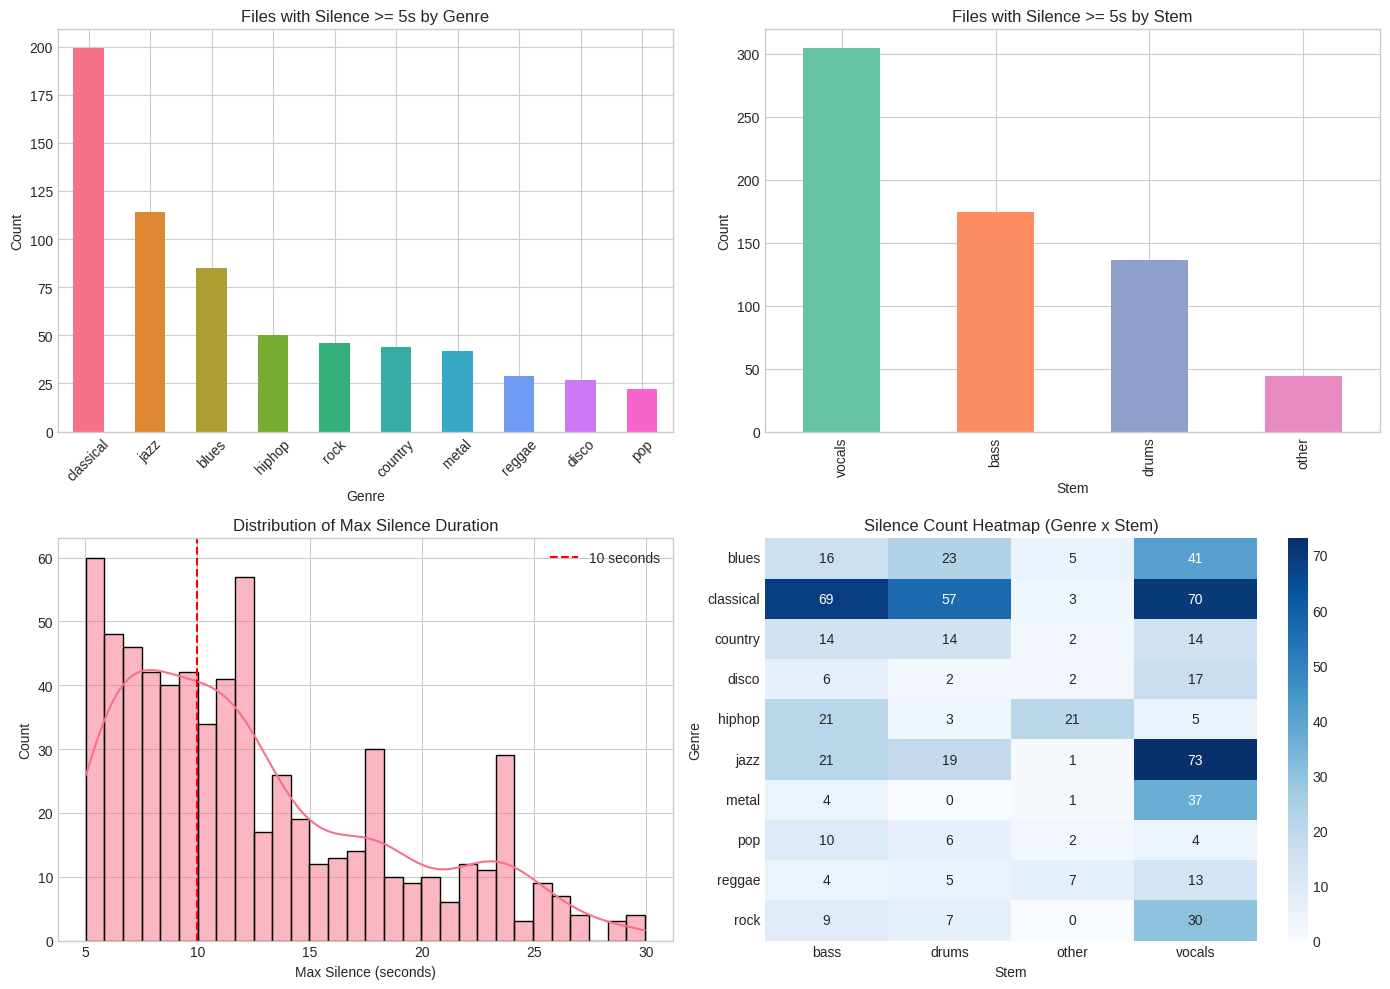

Plot saved as 'silence_analysis.png'


In [18]:

def visualize_silence_analysis(df_silence):
    
    if len(df_silence) == 0:
        print("No silence data to visualize.")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Silence count by genre
    ax1 = axes[0, 0]
    genre_counts = df_silence['Genre'].value_counts()
    genre_counts.plot(kind='bar', ax=ax1, color=sns.color_palette("husl", len(genre_counts)))
    ax1.set_title('Files with Silence >= 5s by Genre')
    ax1.set_xlabel('Genre')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. Silence count by stem
    ax2 = axes[0, 1]
    stem_counts = df_silence['Stem'].value_counts()
    stem_counts.plot(kind='bar', ax=ax2, color=sns.color_palette("Set2", len(stem_counts)))
    ax2.set_title('Files with Silence >= 5s by Stem')
    ax2.set_xlabel('Stem')
    ax2.set_ylabel('Count')
    
    # 3. Max silence duration distribution
    ax3 = axes[1, 0]
    sns.histplot(data=df_silence, x='Max_Silence_Sec', bins=30, kde=True, ax=ax3)
    ax3.axvline(x=10, color='red', linestyle='--', label='10 seconds')
    ax3.set_title('Distribution of Max Silence Duration')
    ax3.set_xlabel('Max Silence (seconds)')
    ax3.legend()
    
    # 4. Heatmap of silence counts (Genre x Stem)
    ax4 = axes[1, 1]
    pivot_silence = pd.pivot_table(df_silence, values='File_Path', index='Genre', 
                                    columns='Stem', aggfunc='count', fill_value=0)
    sns.heatmap(pivot_silence, annot=True, fmt='d', cmap='Blues', ax=ax4)
    ax4.set_title('Silence Count Heatmap (Genre x Stem)')
    
    plt.tight_layout()
    plt.savefig('silence_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Plot saved as 'silence_analysis.png'")

visualize_silence_analysis(df_silence)


## 4.5. *Audio Features Extraction & Visualization*

Extracting audio features...


Extracting features: 100%|██████████| 10/10 [00:30<00:00,  3.00s/it]



FEATURE STATISTICS:
--------------------------------------------------
              rms  zero_crossing_rate  spectral_centroid_mean       tempo  \
count  120.000000          120.000000              120.000000  120.000000   
mean     0.057679            0.151922             2178.376699   84.965105   
std      0.045629            0.135411             1631.421494   55.062685   
min      0.000003            0.001035               61.685621    0.000000   
25%      0.023569            0.049675              806.331031   42.221967   
50%      0.049242            0.110951             2066.248462  101.371695   
75%      0.079403            0.234897             3140.771819  118.852095   
max      0.185961            0.760638             8128.470227  198.768029   

       peak_amplitude  spectral_rolloff_mean  spectral_bandwidth_mean  
count      120.000000             120.000000               120.000000  
mean         0.370327            3659.965803              1519.009601  
std          0.278

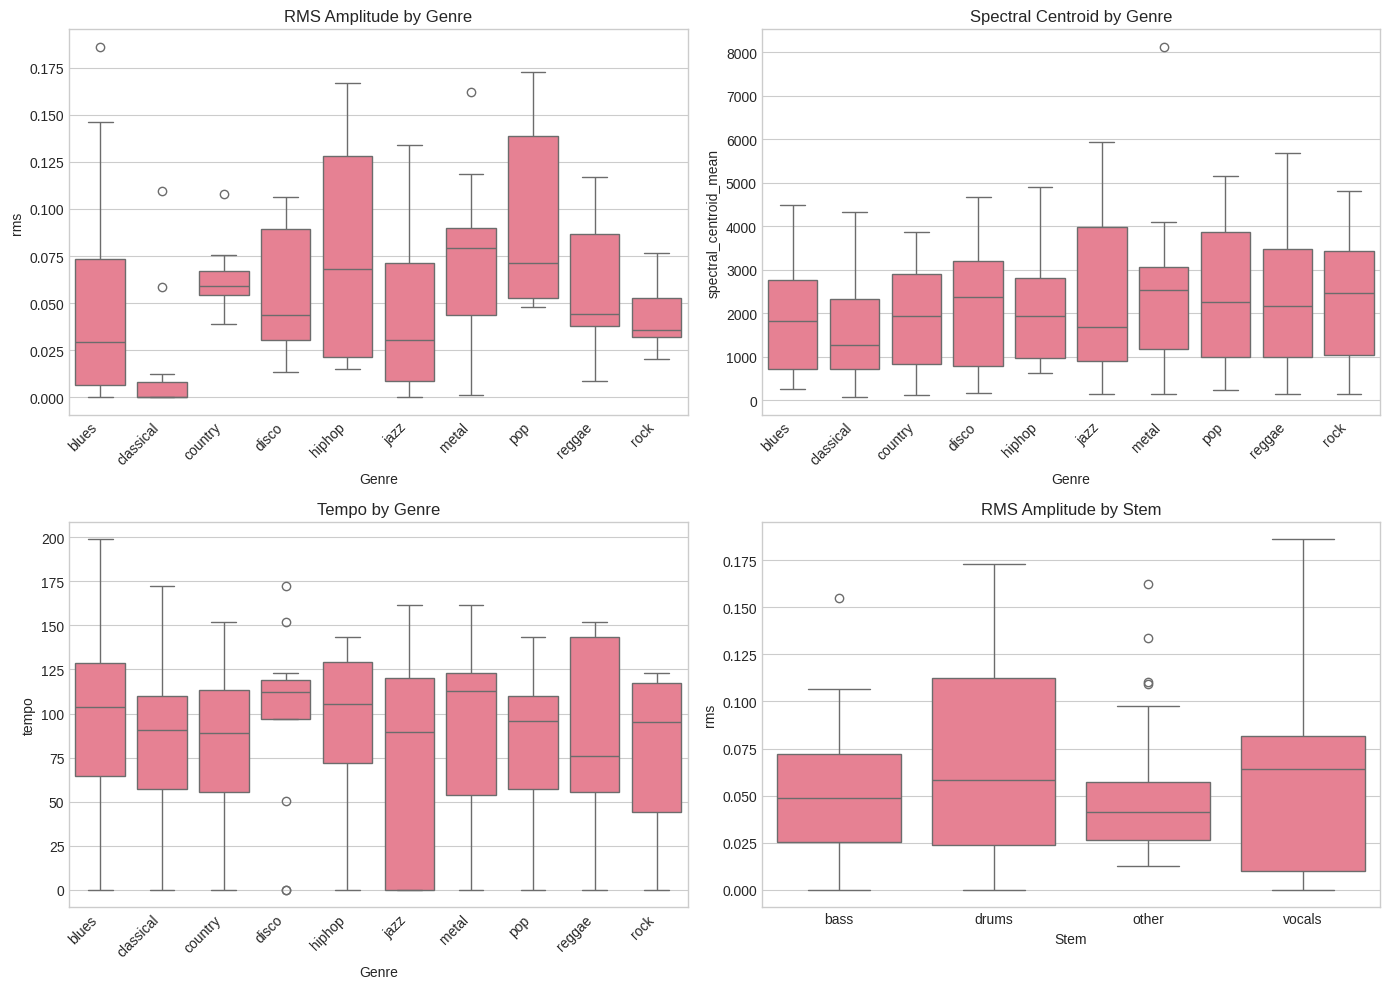

Plot saved as 'audio_features.png'


In [19]:

def extract_audio_features(file_path, sr=SR, duration=DURATION):

    y, _ = librosa.load(file_path, sr=sr, duration=duration)
    
    features = {}
    
    # Time domain features
    features['rms'] = float(np.sqrt(np.mean(y**2)))
    features['zero_crossing_rate'] = float(np.mean(librosa.feature.zero_crossing_rate(y)))
    features['peak_amplitude'] = float(np.max(np.abs(y)))
    
    # Spectral features
    spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    features['spectral_centroid_mean'] = float(np.mean(spectral_centroids))
    features['spectral_centroid_std'] = float(np.std(spectral_centroids))
    
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    features['spectral_rolloff_mean'] = float(np.mean(spectral_rolloff))
    
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    features['spectral_bandwidth_mean'] = float(np.mean(spectral_bandwidth))
    
    # MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f'mfcc_{i+1}_mean'] = float(np.mean(mfccs[i]))
        features[f'mfcc_{i+1}_std'] = float(np.std(mfccs[i]))
    
    tempo_result = librosa.beat.beat_track(y=y, sr=sr)
    
    # Check if tempo is array or scalar
    if isinstance(tempo_result, tuple):
        tempo = tempo_result[0]
    else:
        tempo = tempo_result
    
    # Convert to scalar if array
    if isinstance(tempo, np.ndarray):
        tempo = float(tempo[0]) if len(tempo) > 0 else 0.0
    else:
        tempo = float(tempo)
    
    features['tempo'] = tempo
    
    return features, y


def analyze_genre_features(train_dataset, samples_per_genre=5, sr=SR, duration=DURATION):
   
    feature_data = []
    
    for genre in tqdm(train_dataset, desc="Extracting features"):
        # Sample files from each stem
        for stem in train_dataset[genre]:
            files = train_dataset[genre][stem][:samples_per_genre]
            
            for file_path in files:
                try:
                    features, _ = extract_audio_features(file_path, sr=sr, duration=duration)
                    features['Genre'] = genre
                    features['Stem'] = stem
                    features['File_Path'] = file_path
                    feature_data.append(features)
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")
    
    feature_df = pd.DataFrame(feature_data)
    
    numeric_cols = ['rms', 'zero_crossing_rate', 'spectral_centroid_mean', 'tempo', 
                    'peak_amplitude', 'spectral_rolloff_mean', 'spectral_bandwidth_mean']
    
    for col in numeric_cols:
        if col in feature_df.columns:
            feature_df[col] = pd.to_numeric(feature_df[col], errors='coerce')
    
    
    print("\nFEATURE STATISTICS:")
    print("-"*50)
    available_cols = [col for col in numeric_cols if col in feature_df.columns]
    print(feature_df[available_cols].describe())
    
    return feature_df

print("Extracting audio features...")
feature_df = analyze_genre_features(tr, samples_per_genre=3)


#--------------------Features Visualization------------------------#


def visualize_audio_features(feature_df):
   
    feature_df = feature_df.copy()
    
    numeric_cols = ['rms', 'tempo', 'spectral_centroid_mean', 'zero_crossing_rate']
    for col in numeric_cols:
        if col in feature_df.columns:
            feature_df[col] = pd.to_numeric(feature_df[col], errors='coerce')
    
    # Convert categorical cols to string
    feature_df['Genre'] = feature_df['Genre'].astype(str)
    feature_df['Stem'] = feature_df['Stem'].astype(str)
    
    # Drop rows with NaN in key cols
    feature_df = feature_df.dropna(subset=['rms', 'tempo', 'spectral_centroid_mean'])
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # RMS by Genre
    ax1 = axes[0, 0]
    sns.boxplot(data=feature_df, x='Genre', y='rms', ax=ax1, order=sorted(feature_df['Genre'].unique()))
    ax1.set_title('RMS Amplitude by Genre')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    
    # Spectral Centroid by Genre
    ax2 = axes[0, 1]
    sns.boxplot(data=feature_df, x='Genre', y='spectral_centroid_mean', ax=ax2, order=sorted(feature_df['Genre'].unique()))
    ax2.set_title('Spectral Centroid by Genre')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    
    # Tempo by Genre
    ax3 = axes[1, 0]
    sns.boxplot(data=feature_df, x='Genre', y='tempo', ax=ax3, order=sorted(feature_df['Genre'].unique()))
    ax3.set_title('Tempo by Genre')
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
    
    # RMS by Stem
    ax4 = axes[1, 1]
    sns.boxplot(data=feature_df, x='Stem', y='rms', ax=ax4, order=sorted(feature_df['Stem'].unique()))
    ax4.set_title('RMS Amplitude by Stem')
    
    plt.tight_layout()
    plt.savefig('audio_features.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Plot saved as 'audio_features.png'")

visualize_audio_features(feature_df)


## 4.6. *Features Correlation*

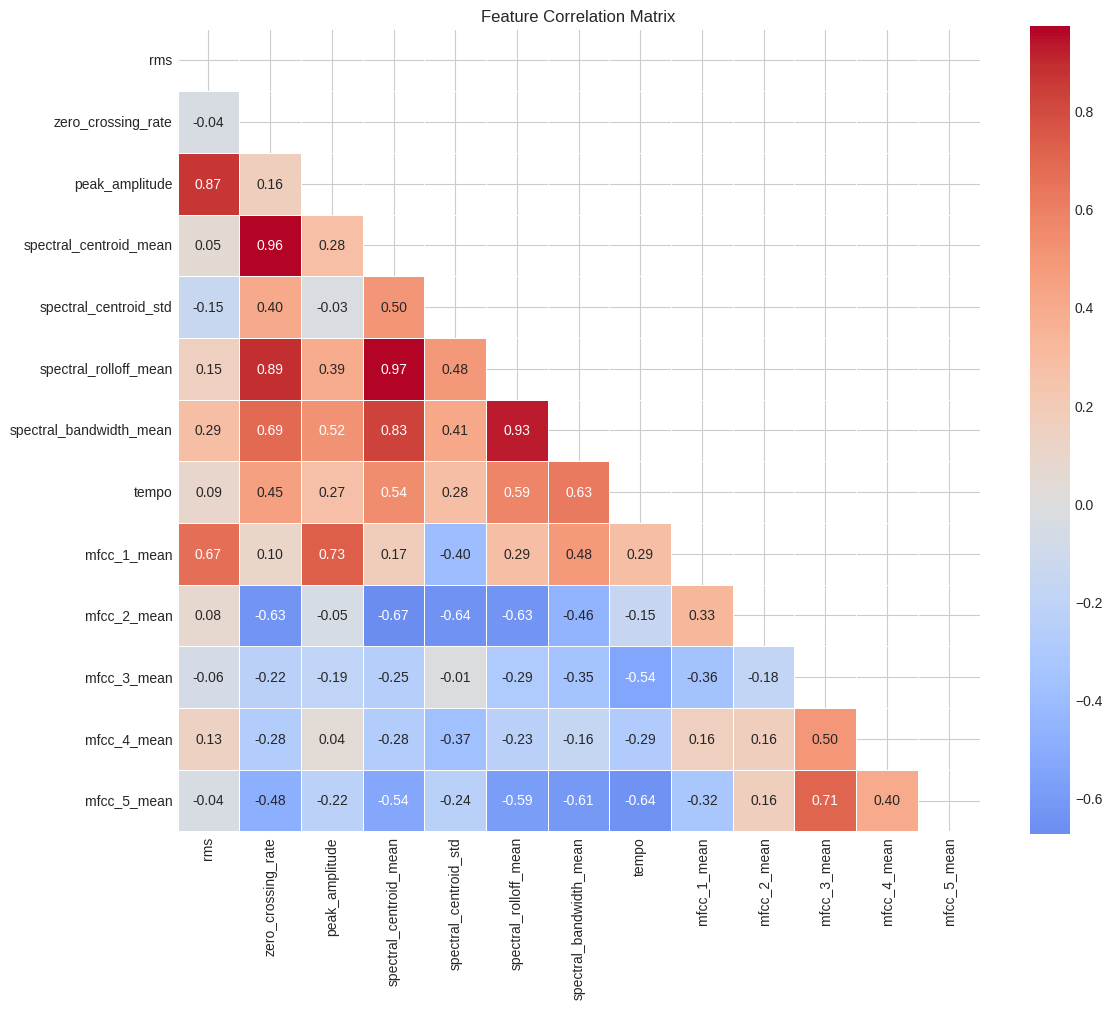

Plot saved as 'feature_correlations.png'


In [20]:

def plot_feature_correlations(feature_df):
   
    numeric_cols = ['rms', 'zero_crossing_rate', 'peak_amplitude', 
                    'spectral_centroid_mean', 'spectral_centroid_std',
                    'spectral_rolloff_mean', 'spectral_bandwidth_mean', 'tempo']
    
    available_cols = [col for col in numeric_cols if col in feature_df.columns]
    
    # MFCC columns
    mfcc_cols = [f'mfcc_{i}_mean' for i in range(1, 6)]
    available_cols.extend([col for col in mfcc_cols if col in feature_df.columns])
    
    # Correlation matrix
    corr_df = feature_df[available_cols].copy()
    for col in available_cols:
        corr_df[col] = pd.to_numeric(corr_df[col], errors='coerce')
    
    corr_matrix = corr_df.corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='coolwarm', center=0, ax=ax,
                square=True, linewidths=0.5)
    
    ax.set_title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.savefig('feature_correlations.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Plot saved as 'feature_correlations.png'")

plot_feature_correlations(feature_df)


## 4.7. *ROCK Genre(Song id-0) Analysis*

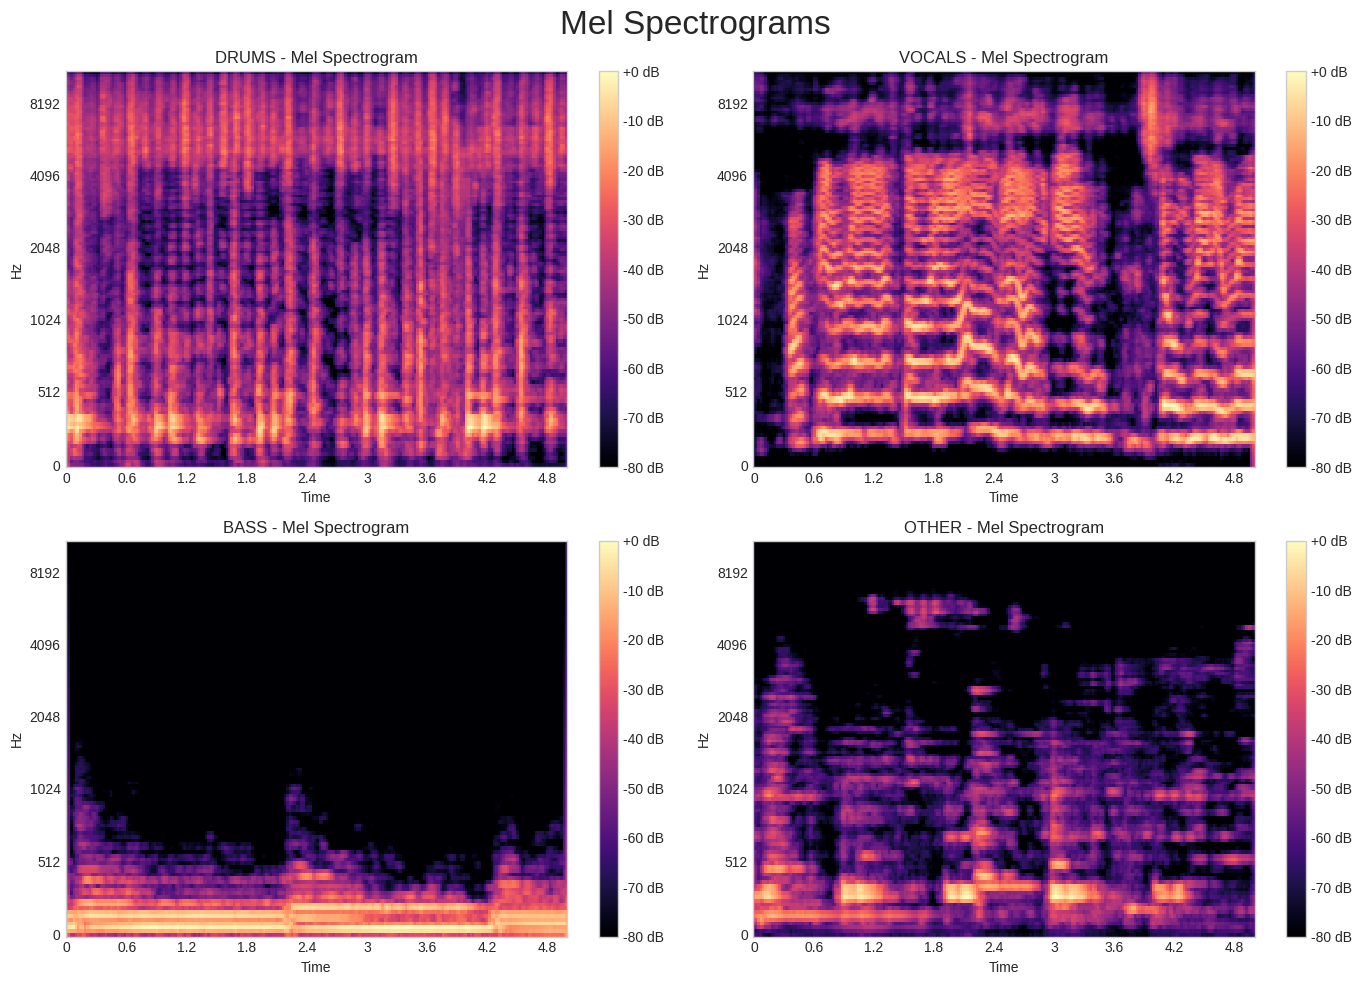

Plot saved as 'spectrograms.png'

            ----------------------------------------------------------------------------------------


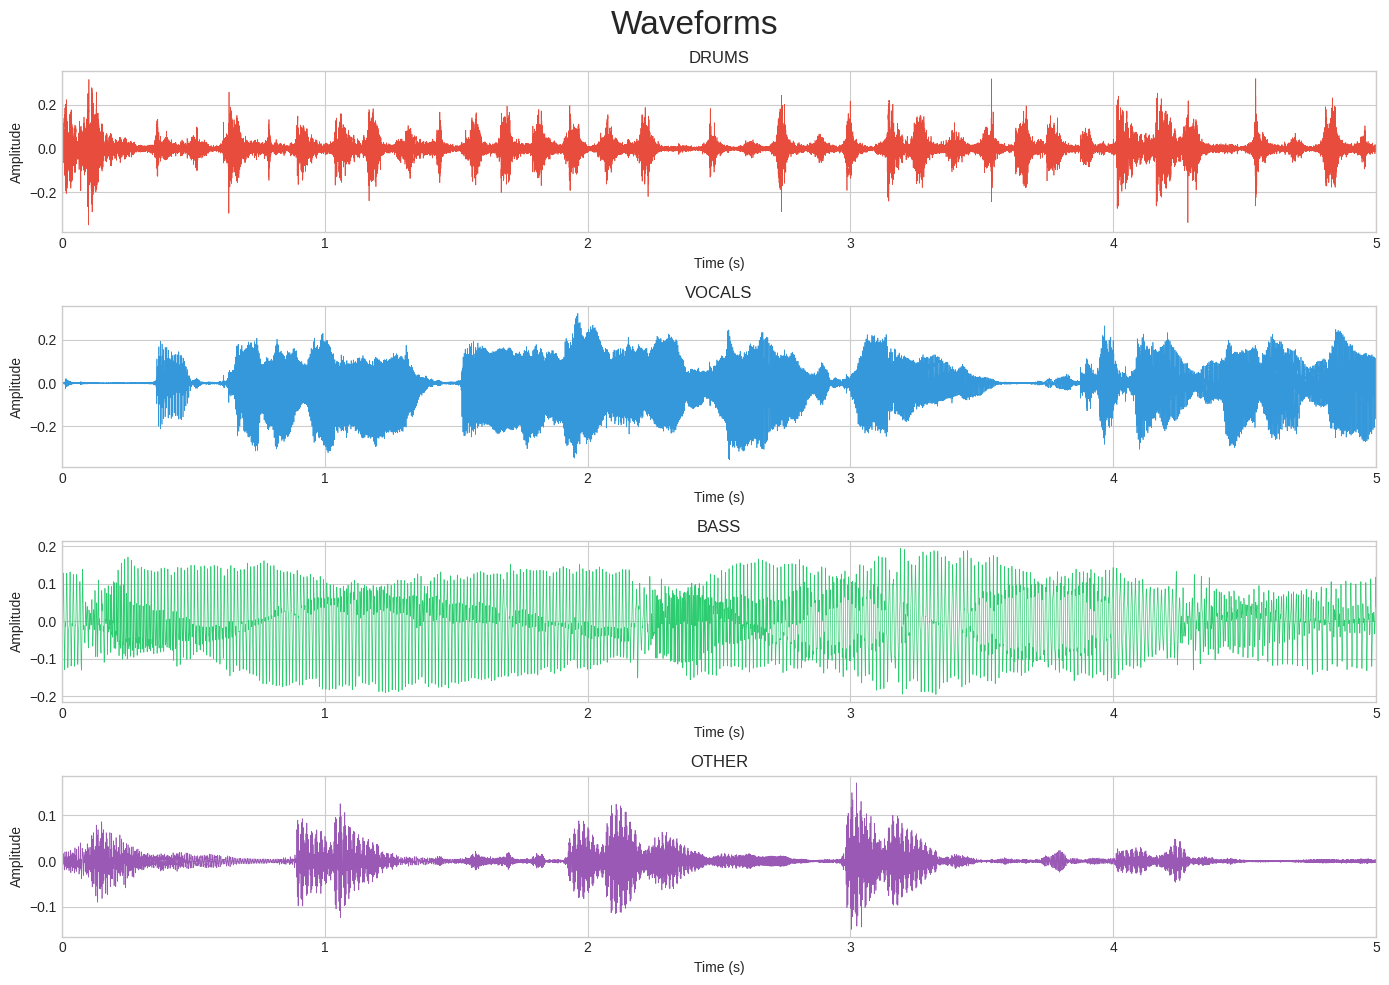

Plot saved as 'waveforms.png'

            ----------------------------------------------------------------------------------------

 DRUMS:
  File: /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/rock/rock.00030/drums.wav



 VOCALS:
  File: /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/rock/rock.00030/vocals.wav



 BASS:
  File: /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/rock/rock.00030/bass.wav



 OTHER:
  File: /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/rock/rock.00030/other.wav


In [26]:
# Spectrogram Visualization

def visualize_spectrograms(train_dataset, genre='rock', song_index=0, sr=SR, duration=DURATION):
 
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    stem_keys = ['drums', 'vocals', 'bass', 'other']
    
    for idx, stem in enumerate(stem_keys):
        file_path = train_dataset[genre][stem][song_index]
        y, _ = librosa.load(file_path, sr=sr, duration=duration)
        
        # mel spectrogram
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, 
                                                   n_fft=N_FFT, hop_length=HOP_LENGTH)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Plot
        ax = axes[idx]
        img = librosa.display.specshow(mel_spec_db, x_axis='time', y_axis='mel', 
                                        sr=sr, hop_length=HOP_LENGTH, ax=ax)
        ax.set_title(f'{stem.upper()} - Mel Spectrogram')
        fig.colorbar(img, ax=ax, format='%+2.0f dB')
    
    plt.suptitle(f'Mel Spectrograms', fontsize=24)
    plt.tight_layout()
    plt.savefig('spectrograms.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Plot saved as 'spectrograms.png'")

visualize_spectrograms(tr, genre='rock', song_index=0)



#-----------------------Waveform Visualization-------------------#

def visualize_waveforms(train_dataset, genre='rock', song_index=0, sr=SR, duration=DURATION):

    print("\n            " + "-"*88)
   
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    
    stem_keys = ['drums', 'vocals', 'bass', 'other']
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
    
    for idx, stem in enumerate(stem_keys):
        file_path = train_dataset[genre][stem][song_index]
        y, _ = librosa.load(file_path, sr=sr, duration=duration)
        
        ax = axes[idx]
        time = np.linspace(0, len(y)/sr, len(y))
        ax.plot(time, y, color=colors[idx], linewidth=0.5)
        ax.set_title(f'{stem.upper()}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')
        ax.set_xlim([0, duration])
    
    plt.suptitle(f'Waveforms', fontsize=24)
    plt.tight_layout()
    plt.savefig('waveforms.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Plot saved as 'waveforms.png'")

visualize_waveforms(tr, genre='rock', song_index=0)



#------------------------Audio Playback----------------------#


def play_audio_samples(train_dataset, genre='rock', song_index=0, sr=SR, duration=DURATION):

    print("\n            " + "-"*88)
    stem_keys = ['drums', 'vocals', 'bass', 'other']
    
    for stem in stem_keys:
        file_path = train_dataset[genre][stem][song_index]
        print(f"\n {stem.upper()}:")
        print(f"  File: {file_path}")
        
        y, _ = librosa.load(file_path, sr=sr, duration=duration)
        display(ipd.Audio(y, rate=sr))

play_audio_samples(tr, genre='rock', song_index=0)


## 4.8. *ESC-50 noise data*

In [34]:

def analyze_esc50(root_dir):
   
    esc_path = os.path.join(root_dir, 'ESC-50-master')
    meta_path = os.path.join(esc_path, 'meta', 'esc50.csv')
    audio_path = os.path.join(esc_path, 'audio')
    
    if not os.path.exists(meta_path):
        print("ESC-50 metadata not found.")
        return None
    
    esc_df = pd.read_csv(meta_path)

    print(f"Total samples: {len(esc_df)}")
    print(f"Number of categories: {esc_df['category'].nunique()}")
    
    print("\nCATEGORIES:")
    print("-"*50)
    category_counts = esc_df['category'].value_counts()
    print(category_counts)

    # Load audio
    audio_files = [f for f in os.listdir(audio_path) if f.endswith('.wav')]

    for file in audio_files[:2]:
        file_path = os.path.join(audio_path, file)
        print(f"\n  File: {file_path}")
        
        y, _ = librosa.load(file_path, sr=SR)
        display(ipd.Audio(y, rate=SR))
    
    return esc_df

esc_df = analyze_esc50(DATA_ROOT)

Total samples: 2000
Number of categories: 50

CATEGORIES:
--------------------------------------------------
category
dog                 40
chirping_birds      40
vacuum_cleaner      40
thunderstorm        40
door_wood_knock     40
can_opening         40
crow                40
clapping            40
fireworks           40
chainsaw            40
airplane            40
mouse_click         40
pouring_water       40
train               40
sheep               40
water_drops         40
church_bells        40
clock_alarm         40
keyboard_typing     40
wind                40
footsteps           40
frog                40
cow                 40
brushing_teeth      40
car_horn            40
crackling_fire      40
helicopter          40
drinking_sipping    40
rain                40
insects             40
laughing            40
hen                 40
engine              40
breathing           40
crying_baby         40
hand_saw            40
coughing            40
glass_breaking      40
snoring 


  File: /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-195557-A-19.wav


## 4.9. *Test data (Mashups)*

In [37]:

def analyze_mashups(root_dir, sample_size=50, sr=SR):

    mashups_path = os.path.join(root_dir, 'mashups')
    test_csv_path = os.path.join(root_dir, 'test.csv')
    
    if not os.path.exists(mashups_path):
        print("Mashups folder not found.")
        return None
    
    test_df = pd.read_csv(test_csv_path)

    print(f"Total test samples: {len(test_df)}")
    print(f"Test.csv columns: {test_df.columns.tolist()}")
    print("\n",test_df.head())
    
    # sample mashup files
    mashup_files = [f for f in os.listdir(mashups_path) if f.endswith('.wav')]
    sampled_files = random.sample(mashup_files, min(sample_size, len(mashup_files)))
    
    mashup_data = []
    
    print(f"\nAnalyzing {len(sampled_files)} sample mashup files...")
    
    for file_name in tqdm(sampled_files, desc="Analyzing mashups"):
        file_path = os.path.join(mashups_path, file_name)
        try:
            y, _ = librosa.load(file_path, sr=sr)
            duration = len(y) / sr
            rms = np.sqrt(np.mean(y**2))
            
            mashup_data.append({
                'File': file_name,
                'Duration_Sec': duration,
                'Samples': len(y),
                'RMS': rms,
                'Peak': np.max(np.abs(y))
            })
        except Exception as e:
            print(f"Error loading {file_name}: {e}")
    
    mashup_df = pd.DataFrame(mashup_data)
    
    print("\nMASHUP FILE STATISTICS:")
    print("-"*50)
    print(mashup_df.describe())
    
    return mashup_df, test_df

mashup_df, test_df = analyze_mashups(DATA_ROOT, sample_size=100)

Total test samples: 3020
Test.csv columns: ['id', 'filename']

    id              filename
0   1  mashups/song0001.wav
1   2  mashups/song0002.wav
2   3  mashups/song0003.wav
3   4  mashups/song0004.wav
4   5  mashups/song0005.wav

Analyzing 100 sample mashup files...


Analyzing mashups: 100%|██████████| 100/100 [00:02<00:00, 36.05it/s]


MASHUP FILE STATISTICS:
--------------------------------------------------
       Duration_Sec        Samples         RMS        Peak
count    100.000000     100.000000  100.000000  100.000000
mean      28.714424  633153.060000    0.138896    0.999130
std        3.506013   77307.597225    0.020670    0.005679
min        8.591383  189440.000000    0.089349    0.946228
25%       29.395374  648168.000000    0.124869    0.999969
50%       29.920454  659746.000000    0.137457    1.000000
75%       30.000181  661504.000000    0.153731    1.000000
max       30.400907  670340.000000    0.185604    1.000000
